In [ ]:
!pip install qiskit-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.5/646.5 kB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.7 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.30.251-py3-none-any.whl size=685954 sha256=1d94ddc20b4cbb9cf6e186e01daa137baca52d492c3019a60ea58c631594c952
  Stored in directory: /root/.cache/pip/wheels/c1/d9/5c/1d919b1e441ebbaff244513a13d09c3c0378401601d4184bb0
Successfully built docplex


In [ ]:
import networkx as nx
from qiskit_optimization.applications.vertex_cover import VertexCover
import qiskit
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

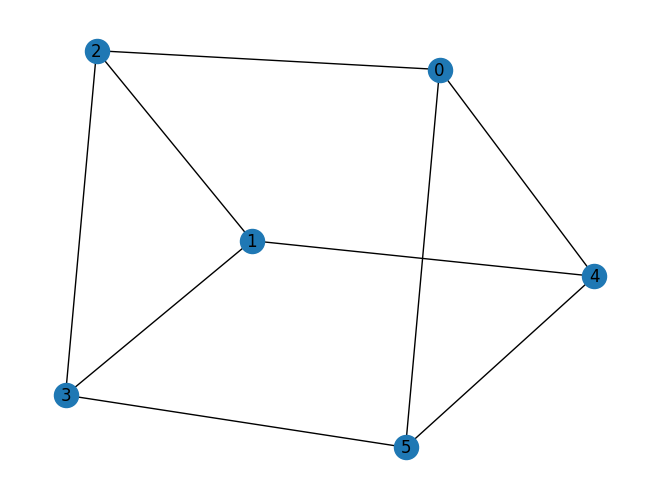

In [ ]:
graph = nx.random_regular_graph(3,6,123)
pos = nx.spring_layout(graph)
prob = VertexCover(graph)
prob.draw(pos=pos)

In [ ]:
qp = prob.to_quadratic_program()
print(qp.prettyprint())

Problem name: Vertex cover

Minimize
  x_0 + x_1 + x_2 + x_3 + x_4 + x_5

Subject to
  Linear constraints (9)
    x_0 + x_4 >= 1  'c0'
    x_0 + x_2 >= 1  'c1'
    x_0 + x_5 >= 1  'c2'
    x_1 + x_2 >= 1  'c3'
    x_1 + x_4 >= 1  'c4'
    x_1 + x_3 >= 1  'c5'
    x_2 + x_3 >= 1  'c6'
    x_3 + x_5 >= 1  'c7'
    x_4 + x_5 >= 1  'c8'

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



objective function value: 4.0
variable values: x_0=0.0, x_1=0.0, x_2=1.0, x_3=1.0, x_4=1.0, x_5=1.0
status: SUCCESS

solution: [2, 3, 4, 5]


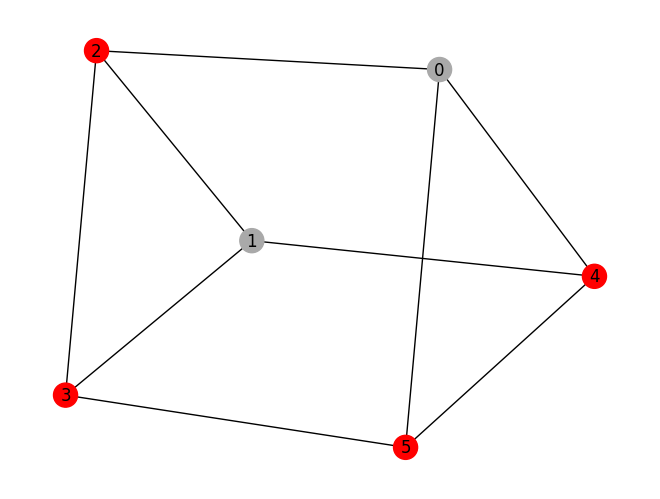

In [ ]:

meo = MinimumEigenOptimizer(min_eigen_solver=NumPyMinimumEigensolver())
result = meo.solve(qp)
print(result.prettyprint())
print("\nsolution:", prob.interpret(result))
prob.draw(result, pos=pos)

objective function value: 4.0
variable values: x_0=1.0, x_1=0.0, x_2=1.0, x_3=1.0, x_4=1.0, x_5=0.0
status: SUCCESS

solution: [0, 2, 3, 4]

time: 0.4494900703430176


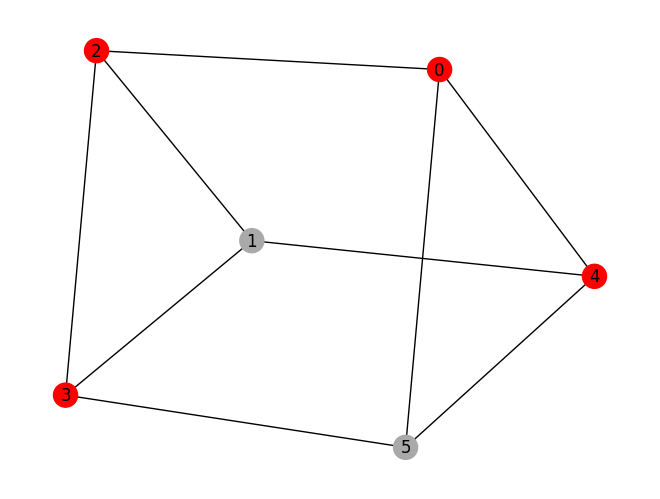

In [ ]:

meo = MinimumEigenOptimizer(
    min_eigen_solver= QAOA(
        reps= 1, sampler = StatevectorSampler(seed= 123), optimizer= COBYLA()
    )
    )
result = meo.solve(qp)
print(result.prettyprint())
print("\nsolution:", prob.interpret(result))
print("\ntime:", result.min_eigen_solver_result.optimizer_time)
prob.draw(result, pos=pos)